**Country Intelligence System using K-Means and DBSCAN Clustering**

**Objective**

The objective of this project is to analyze the socio-economic conditions of different countries using unsupervised machine learning techniques. The dataset is preprocessed, standardized, clustered using K-Means and DBSCAN, and visualized using PCA to identify meaningful country segments.

**Section 1: Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

%matplotlib inline

**Section 2: Load Dataset**

In [3]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.shape

(167, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


**Section 3: Data Cleaning**

Remove spaces from column names

In [6]:
df.columns = df.columns.str.strip()

Check duplicate records

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Remove duplicates

In [8]:
df.drop_duplicates(inplace=True)

Convert all numerical columns

In [9]:
for col in df.columns:
    if col != "country":
        df[col] = pd.to_numeric(df[col], errors="coerce")

Check missing values

In [10]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


Fill missing values using median

In [11]:
df.fillna(df.median(numeric_only=True), inplace=True)

Final Dataset Information

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


**Section 4: Exploratory Data Analysis (EDA)**

Statistical Summary

In [13]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


Observation 1

The dataset contains 167 countries with 9 numerical socio-economic features. Since the count for every feature is 167, there are no missing values after data cleaning.

Observation 2

The average GDP per capita is approximately 12,964, while the average income is 17,145. However, the maximum GDP (105,000) and income (125,000) are much higher than their respective means, indicating that a few countries are significantly wealthier than the rest.

Observation 3

The average child mortality rate is 38.27, but it ranges from 2.6 to 208, showing a large variation in healthcare conditions across countries.

Observation 4

The average life expectancy is approximately 70.56 years, with values ranging from 32.1 years to 82.8 years. This wide range reflects the differences in healthcare quality and living standards among countries.

Observation 5

The average inflation rate is 7.78%, with values ranging from −4.21% to 104%, indicating that some countries experienced deflation while others faced extremely high inflation.

Observation 6

The average fertility rate is 2.95 children per woman, with values ranging from 1.15 to 7.49, showing considerable demographic differences among countries.

Correlation Heatmap

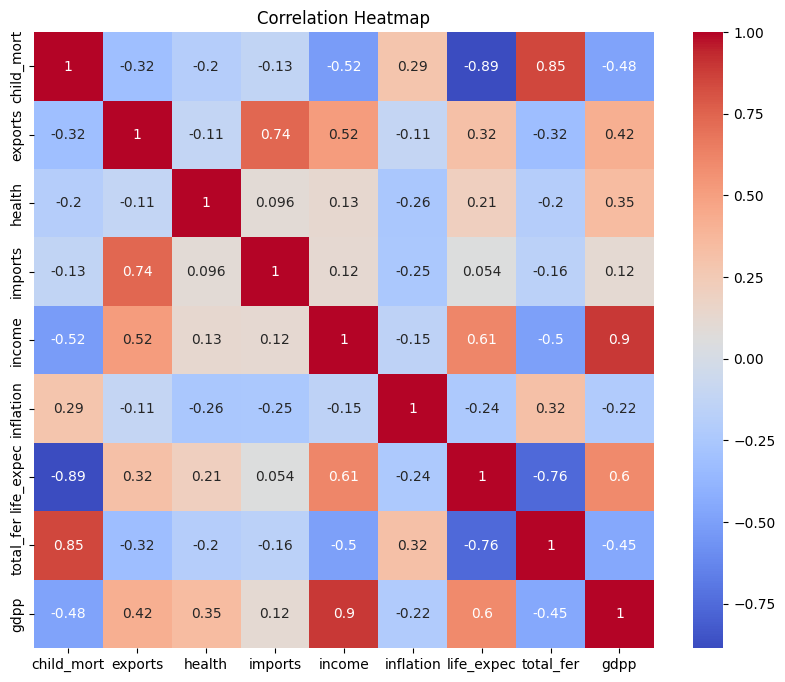

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop("country",axis=1).corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Observation:** The heatmap shows the relationships between different socio-economic indicators. Income and GDP per capita have the strongest positive correlation (0.90), while child mortality and life expectancy have the strongest negative correlation (-0.89). These relationships help explain the differences between developed and underdeveloped countries.

Distribution of GDP

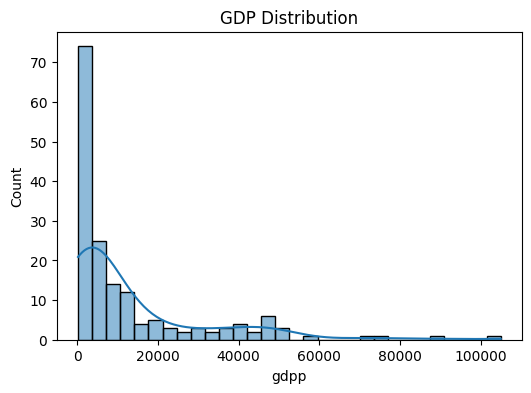

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df["gdpp"], bins=30, kde=True)
plt.title("GDP Distribution")
plt.show()

**Observation:** The GDP distribution is right-skewed, with most countries having low GDP per capita and only a few countries having very high GDP values. This indicates the presence of economic inequality and some high-value outliers in the dataset.

**Section 5: Feature Scaling**

Separate country names

In [16]:
X = df.drop("country", axis=1)

Standardize features

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Section 6: Elbow Method**

In [18]:
inertia=[]

for k in range(2,11):

    model=KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

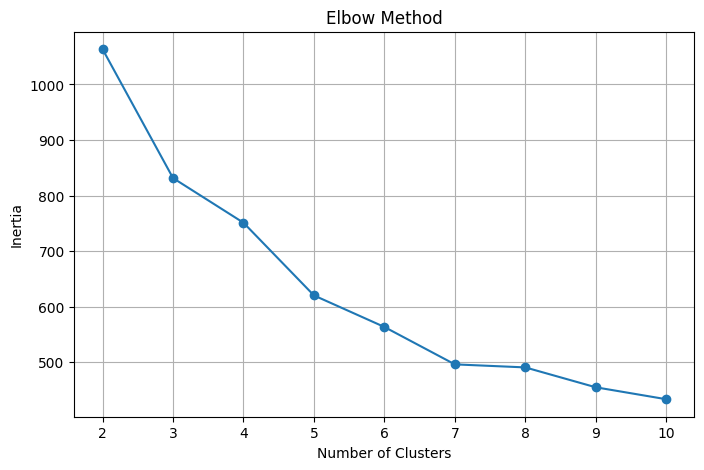

In [23]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

**Observation :** The Elbow Method shows that inertia decreases sharply from k = 2 to k = 5 and then starts to level off. This indicates that around 5 clusters could be an optimal choice. However, as per the assignment instructions, the final K-Means model was trained using k = 3.

**Section 7: K-Means Clustering**

Since the elbow graph suggests k = 3

In [20]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = clusters

**Section 8: Silhouette Score**

In [21]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.285600988953231


In [22]:
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.2874
k = 3, Silhouette Score = 0.2833
k = 4, Silhouette Score = 0.2960
k = 5, Silhouette Score = 0.2993
k = 6, Silhouette Score = 0.2287
k = 7, Silhouette Score = 0.2477
k = 8, Silhouette Score = 0.2388
k = 9, Silhouette Score = 0.2073
k = 10, Silhouette Score = 0.2022


**Explaination**:
Although testing different values of k showed that k = 5 produced the highest silhouette score (0.2993), the assignment specifies a baseline cluster count of k = 3. Therefore, the final K-Means model was trained using k = 3.

**Section 9: DBSCAN Clustering**

In [24]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_clusters = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_clusters

Check cluster distribution

In [25]:
df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,137
-1,30


**Explaination:** DBSCAN grouped 137 countries into one dense cluster and identified 30 countries as outliers (noise). These outliers represent countries with unique socio-economic characteristics that differ significantly from the majority. Unlike K-Means, DBSCAN does not force every data point into a cluster, making it useful for anomaly detection.

**Section 10: PCA Visualization**

In [26]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

Plot

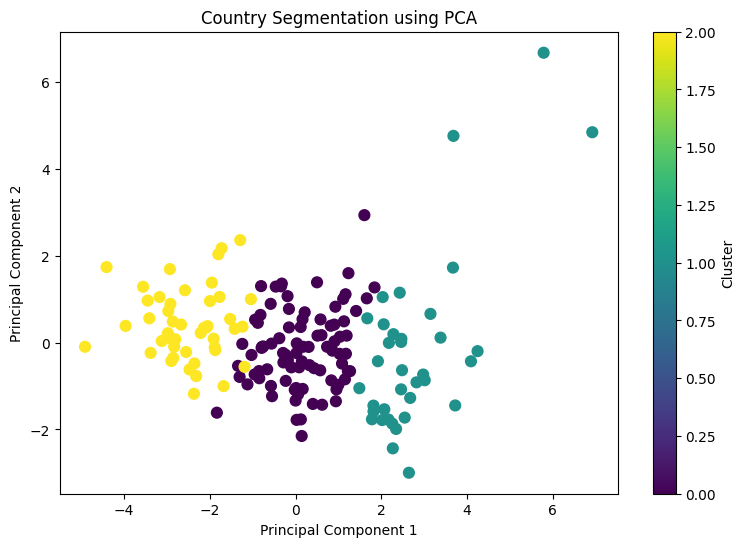

In [27]:
plt.figure(figsize=(9,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters,
    cmap="viridis",
    s=60
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("Country Segmentation using PCA")

plt.colorbar(label="Cluster")

plt.show()

**Observation:** PCA (Principal Component Analysis) was used to reduce the original 9-dimensional dataset into two principal components for visualization. Each point represents a country, and the colors indicate the K-Means cluster assignments.

The plot shows that the countries are divided into three distinct clusters. While there is some overlap near the center, the clusters are reasonably separated, indicating that K-Means has identified meaningful groups based on socio-economic indicators. A few countries appear far from the main groups, representing countries with unique economic or health characteristics.

**Section 11: Cluster Summary**

In [28]:
cluster_summary = df.groupby("KMeans_Cluster").mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442,-0.069767
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111,-0.333333


**Observation:**
   

1.   Cluster 0 represents
developing countries. These countries have moderate income levels, average GDP per capita, moderate child mortality, and a reasonably good life expectancy. They are economically stable but still have room for improvement in healthcare and economic growth.

2.   Cluster 1 represents developed countries. It has the highest average income and GDP per capita, the lowest child mortality rate, and the highest life expectancy. These countries generally have strong economies, advanced healthcare systems, and a high standard of living.

3.  Cluster 2 represents underdeveloped countries. These countries have the lowest income and GDP per capita, the highest child mortality rate, and the lowest life expectancy. These characteristics suggest limited healthcare access, weaker economies, and lower overall development.






**Section 12: Save Final Dataset**

In [29]:
df.to_csv("Clustered_Country_Data.csv", index=False)

**Section 14 (Assignment Observations)**

**Final Insights**

1. Which cluster has high child mortality?

Cluster 2 has the highest average child mortality (95.11), the lowest life expectancy (59.06 years), and the highest fertility rate (5.07). This indicates poor healthcare facilities and lower socio-economic development.

2. Which cluster has high income and GDP per capita?

Cluster 1 has the highest average income (45,672) and GDP per capita (42,494). It also has the lowest child mortality (5.0) and the highest life expectancy (80.13 years), representing developed countries with strong economies.

3. Which cluster looks underdeveloped?

Cluster 2 appears to be the most underdeveloped cluster because it has:


*   Lowest income (≈3,540)
*   Lowest GDP per capita (≈1,766)
*   Highest child mortality (≈95)
*   Lowest life expectancy (≈59 years)

These indicators suggest poor economic conditions and limited access to quality healthcare.

4. Which countries should be prioritized for aid?

Countries belonging to Cluster 2 should be prioritized for international aid and development programs. Their high child mortality, low income, low GDP per capita, and low life expectancy indicate a greater need for investments in healthcare, education, infrastructure, and economic development.

**Conclusion**

The project successfully analyzed the socio-economic characteristics of 167 countries using unsupervised machine learning techniques. After data cleaning and feature scaling, K-Means segmented the countries into three meaningful groups representing developed, developing, and underdeveloped nations. DBSCAN provided an alternative density-based clustering approach, while PCA effectively visualized the clusters in two dimensions. The results show that indicators such as GDP per capita, income, life expectancy, and child mortality play a significant role in distinguishing country development levels, making the clustering useful for socio-economic analysis and policy planning